# 数据集划分与异常样本合成

## 一、环境配置与数据加载

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据路径
processed_path = '../data/processed/'

### 1.1 加载预处理阶段的输出结果

In [18]:
# 加载标准化特征矩阵与特征名
feature_matrix = np.load(os.path.join(processed_path, 'feature_matrix.npy'))
feature_names = np.load(os.path.join(processed_path, 'feature_names.npy'), allow_pickle=True)

# 加载平滑后的完整轨迹数据与元信息
smoothed_trajs = joblib.load(os.path.join(processed_path, 'smoothed_trajectories.pkl'))
# 加载原始标准化器（用于逆变换得到原始特征值）
base_scaler = joblib.load(os.path.join(processed_path, 'feature_scaler.pkl'))

# 重新生成元数据（与轨迹索引一一对应）
metadata = []
day_labels = []
for i, traj in enumerate(smoothed_trajs):
    # 从轨迹中提取天数信息（与加载逻辑对应）
    day = int(traj.attrs.get('day', 1)) if hasattr(traj, 'attrs') else 1
    metadata.append({'traj_id': i, 'day': day})
    day_labels.append(day)

print(f"数据加载完成")
print(f"总轨迹数: {len(smoothed_trajs)} 条")
print(f"特征矩阵维度: {feature_matrix.shape}")
print(f"特征维度: {len(feature_names)} 维")
print(f"特征列表: {list(feature_names)}")

数据加载完成
总轨迹数: 83469 条
特征矩阵维度: (83469, 21)
特征维度: 21 维
特征列表: ['avg_speed', 'max_speed', 'std_speed', 'speed_cv', 'avg_dir_change', 'max_dir_change', 'std_dir_change', 'avg_facing_deviation', 'max_facing_deviation', 'path_length', 'start_end_dist', 'tortuosity', 'low_speed_ratio', 'duration', 'center_x', 'center_y', 'max_acceleration', 'std_acceleration', 'turn_frequency', 'angle_entropy', 'direction_reversal_rate']


## 二、训练集与测试集划分

In [19]:
# 全体正常轨迹索引
all_indices = np.arange(len(smoothed_trajs))

# 按7:3比例分层划分，按天分层保证数据分布一致
train_idx, test_normal_idx = train_test_split(
    all_indices,
    test_size=0.3,
    stratify=day_labels,
    random_state=42
)

# 提取训练集、测试集正常样本的21维标准化特征
X_train_std_base = feature_matrix[train_idx]
X_test_normal_std_base = feature_matrix[test_normal_idx]
y_test_normal = np.zeros(len(test_normal_idx), dtype=int)

print(f"训练集样本数: {len(train_idx)} 条（纯正常，用于聚类）")
print(f"测试集正常样本数: {len(test_normal_idx)} 条")
print(f"训练集占比: {len(train_idx)/len(all_indices):.2%}")

训练集样本数: 58428 条（纯正常，用于聚类）
测试集正常样本数: 25041 条
训练集占比: 70.00%


## 三、三类异常样本合成算法

### 工具函数：角度周期处理&新增2维禁区距离特征

In [33]:
def angle_diff(angles):
    """计算角度差分，处理0-2π周期性"""
    diff = np.diff(angles)
    return np.arctan2(np.sin(diff), np.cos(diff))

def angle_add(angles, delta):
    """角度叠加，保持在[-π, π]区间"""
    return np.arctan2(np.sin(angles + delta), np.cos(angles + delta))

def compute_forbidden_features(traj_df, forbid_center_x, forbid_center_y, forbid_radius=5000):
    """
    计算单条轨迹的2维禁区距离特征
    禁区半径扩大为5000mm（5米），匹配真实场景禁区规模
    返回: [min_dist_to_forbidden, in_forbidden_ratio]
    """
    x = traj_df['pos_x_smooth'].values
    y = traj_df['pos_y_smooth'].values
    
    # 每个点到禁区中心的欧氏距离
    dists = np.sqrt((x - forbid_center_x)**2 + (y - forbid_center_y)**2)
    
    # 特征1：到禁区的最小距离
    min_dist_to_forbidden = np.min(dists)
    # 特征2：落入禁区内的时间占比
    in_forbidden_ratio = np.sum(dists < forbid_radius) / len(dists)
    
    return np.array([min_dist_to_forbidden, in_forbidden_ratio])

### 3.1 奔跑异常

In [34]:
def synthesize_running(traj_df, n_segments_range=(1, 2), 
                       segment_ratio_range=(0.15, 0.3), 
                       speed_factor_range=(4.0, 10.0)):
    """
    优化版奔跑异常合成：随机选取1-2段局部路径进行速度冲刺放大
    更贴合真实奔跑场景：行人并非全程快跑，而是短距离加速冲刺，随后恢复步行
    强化加速度特征差异，显著区分奔跑与正常快走
    """
    traj = traj_df.copy().reset_index(drop=True)
    n = len(traj)
    if n < 20:
        return traj
    
    # 随机生成冲刺段数量
    n_segments = np.random.randint(n_segments_range[0], n_segments_range[1] + 1)
    
    # 生成不重叠的冲刺段
    segments = []
    remaining_start = 0
    for i in range(n_segments):
        # 每段长度占总长度的 15%-30%
        seg_len = int(n * np.random.uniform(*segment_ratio_range))
        seg_len = max(5, seg_len)  # 至少5帧
        
        # 随机起始位置，保证不重叠、不越界
        max_start = n - seg_len - (n_segments - i - 1) * 5
        if max_start <= remaining_start:
            break
        start = np.random.randint(remaining_start, max_start)
        end = start + seg_len
        
        # 每段随机独立的冲刺倍率
        factor = np.random.uniform(*speed_factor_range)
        segments.append((start, end, factor))
        
        # 更新下一段的起始位置，留间隔避免连续
        remaining_start = end + 3
    
    # 对每个冲刺段放大速度
    for start, end, factor in segments:
        traj.loc[start:end-1, 'velocity_smooth'] *= factor
    
    return traj

### 3.2 徘徊异常

In [35]:
def synthesize_loitering(traj_df, n_segments_range=(2, 3),
                         repeat_per_segment=(2, 5),
                         speed_factor_range=(0.1, 0.2),
                         jitter_range=(-80, 80)):
    """
    优化版徘徊异常合成：随机选取2-3个不同位置插入多轮往复路径
    每段往复加入微小随机偏移，避免完全原路返回，大幅提升转向频率与迂回度
    显著增强方向熵、方向反转率、低速占比等特征，与正常迂回轨迹彻底区分
    """
    traj = traj_df.copy().reset_index(drop=True)
    n = len(traj)
    if n < 30:
        return traj
    
    # 随机确定徘徊段数量
    n_segments = np.random.randint(n_segments_range[0], n_segments_range[1] + 1)
    
    # 将轨迹大致均分，每个区间内选一个徘徊点，保证不重叠
    segment_interval = n // n_segments
    result_parts = []
    last_end = 0
    
    for seg_idx in range(n_segments):
        # 当前区间范围
        seg_start_frame = seg_idx * segment_interval
        seg_end_frame = min((seg_idx + 1) * segment_interval, n)
        
        # 在区间内随机选取徘徊基础段
        base_len = int(segment_interval * 0.4)
        base_len = max(8, base_len)
        center = np.random.randint(seg_start_frame + base_len//2, seg_end_frame - base_len//2)
        base_start = center - base_len//2
        base_end = center + base_len//2
        
        # 先拼接徘徊段之前的正常路径
        result_parts.append(traj.iloc[last_end:base_start].reset_index(drop=True))
        
        # 提取基础徘徊片段
        base_seg = traj.iloc[base_start:base_end].copy().reset_index(drop=True)
        
        # 生成反向片段，角度反转180度
        rev_seg = base_seg.iloc[::-1].copy().reset_index(drop=True)
        rev_seg['motion_angle_smooth'] = angle_add(rev_seg['motion_angle_smooth'], np.pi)
        rev_seg['facing_angle_smooth'] = angle_add(rev_seg['facing_angle_smooth'], np.pi)
        
        # 降低徘徊段速度
        speed_factor = np.random.uniform(*speed_factor_range)
        base_seg['velocity_smooth'] *= speed_factor
        rev_seg['velocity_smooth'] *= speed_factor
        
        # 每轮往复加入微小随机坐标偏移，避免完全重合，增加转向复杂度
        jitter_x = np.random.uniform(*jitter_range)
        jitter_y = np.random.uniform(*jitter_range)
        rev_seg['pos_x_smooth'] += jitter_x
        rev_seg['pos_y_smooth'] += jitter_y
        
        # 插入多轮往复
        repeat = np.random.randint(repeat_per_segment[0], repeat_per_segment[1] + 1)
        for _ in range(repeat):
            result_parts.append(base_seg.copy())
            result_parts.append(rev_seg.copy())
        
        # 更新下一段的起始位置
        last_end = base_end
    
    # 拼接最后一段剩余的正常路径
    result_parts.append(traj.iloc[last_end:].reset_index(drop=True))
    
    # 合并所有片段
    result = pd.concat(result_parts, ignore_index=True)
    return result

### 3.3 闯入禁区异常

In [45]:
def get_forbidden_zone(train_traj_indices, smoothed_trajs):
    """
    基于训练集轨迹分布确定禁区：向正常分布外大幅偏移5000mm
    仅使用训练集数据，严格无数据泄露
    """
    all_x = []
    all_y = []
    for idx in train_traj_indices:
        traj = smoothed_trajs[idx]
        all_x.extend(traj['pos_x_smooth'].values)
        all_y.extend(traj['pos_y_smooth'].values)
    
    all_x = np.array(all_x)
    all_y = np.array(all_y)
    
    # 以1%分位数为边界，左上角为禁区，外扩5000mm（原2000mm）
    x_min = np.percentile(all_x, 1)
    y_max = np.percentile(all_y, 99)
    
    forbidden_center_x = x_min - 5000  # 向左大幅外扩
    forbidden_center_y = y_max + 5000  # 向上大幅外扩
    
    return forbidden_center_x, forbidden_center_y

# 计算禁区坐标（仅用训练集数据，避免数据泄露）
forbid_x, forbid_y = get_forbidden_zone(train_idx, smoothed_trajs)
print(f"禁区中心坐标: ({forbid_x:.0f}, {forbid_y:.0f}) mm")

def synthesize_trespassing(traj_df, forbid_center_x, forbid_center_y):
    """
    优化版闯入禁区异常合成：整条轨迹整体平移至禁区深处
    保证轨迹完全落入禁区范围内，最大化位置特征与禁区特征的区分度
    """
    traj = traj_df.copy().reset_index(drop=True)
    n = len(traj)
    if n < 10:
        return traj
    
    # 计算原轨迹中心点
    center_x = traj['pos_x_smooth'].mean()
    center_y = traj['pos_y_smooth'].mean()
    
    # 计算整体偏移量，将整条轨迹中心精准移到禁区中心
    dx = forbid_center_x - center_x
    dy = forbid_center_y - center_y
    
    # 全轨迹坐标整体平移
    traj['pos_x_smooth'] += dx
    traj['pos_y_smooth'] += dy
    
    return traj

禁区中心坐标: (-40525, 20595) mm


### 3.4 单条异常合成效果可视化

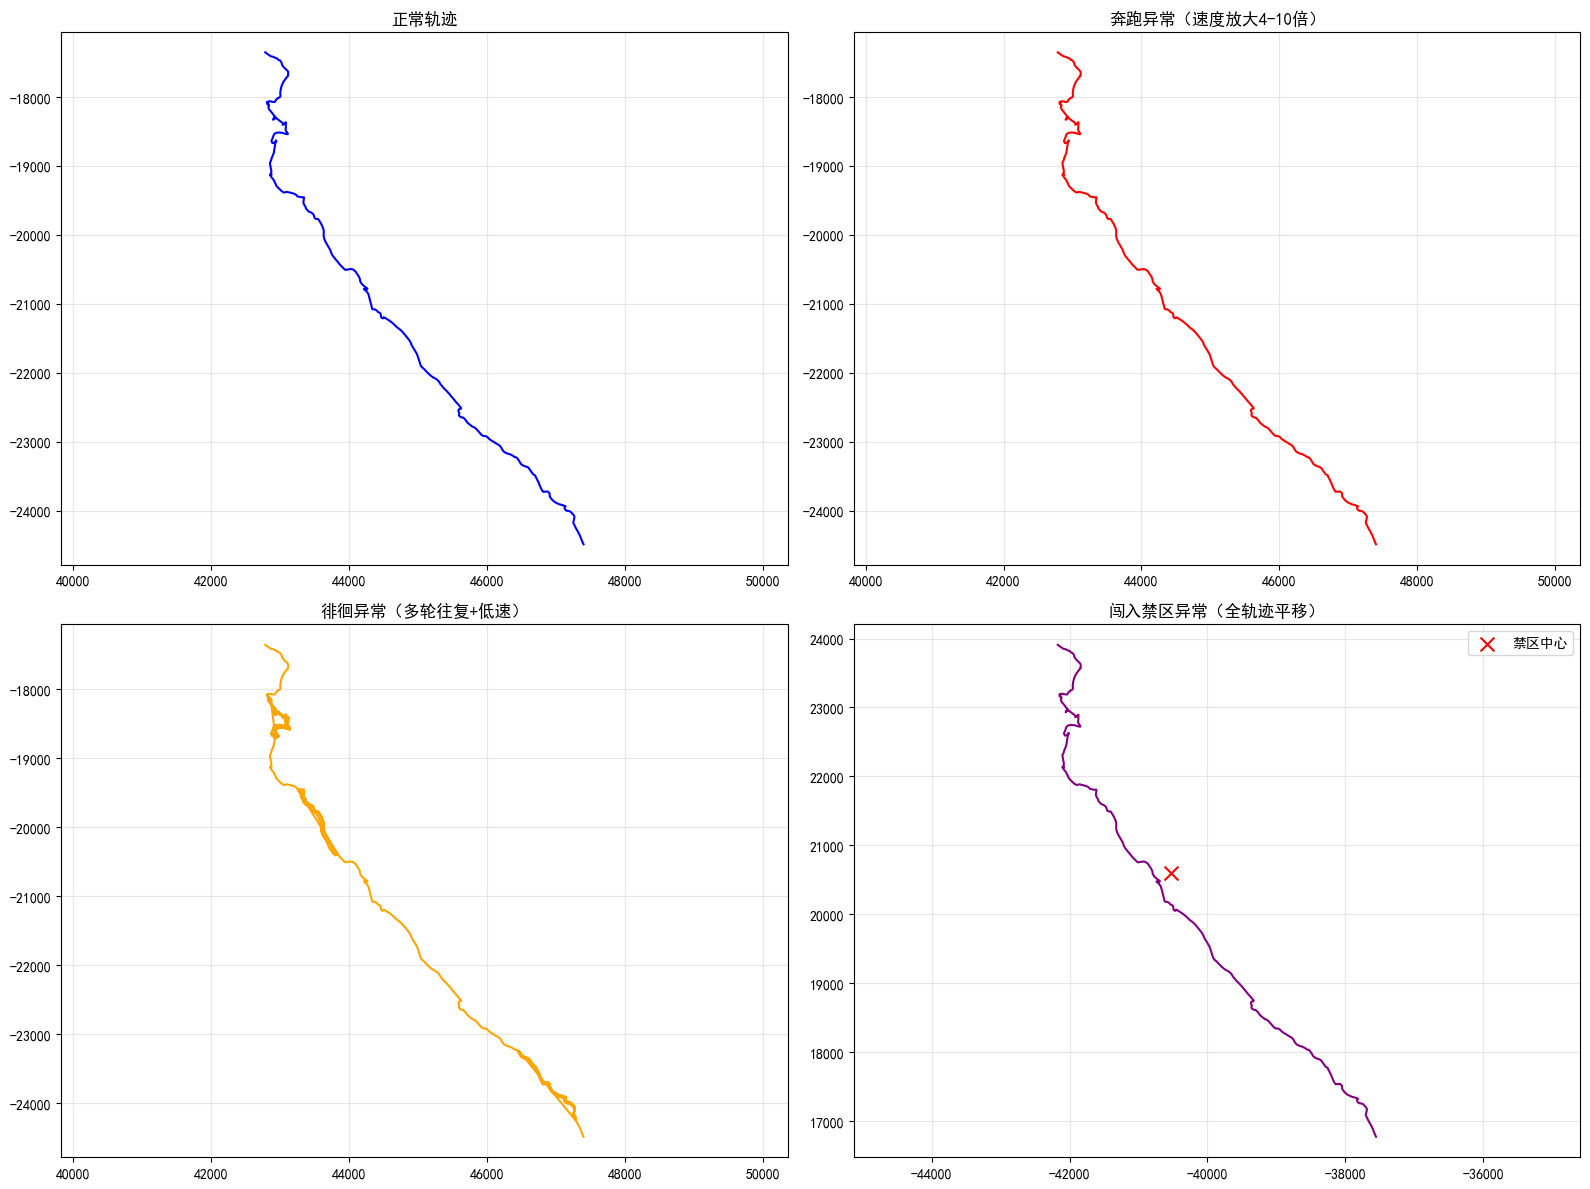

In [46]:
# 随机选一条测试集正常轨迹，合成三类异常并对比
sample_idx = test_normal_idx[10]
normal_sample = smoothed_trajs[sample_idx]

running_sample = synthesize_running(normal_sample)
loitering_sample = synthesize_loitering(normal_sample)
trespassing_sample = synthesize_trespassing(normal_sample, forbid_x, forbid_y)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 正常轨迹
axes[0].plot(normal_sample['pos_x_smooth'], normal_sample['pos_y_smooth'], 'b-', linewidth=1.5)
axes[0].set_title('正常轨迹')
axes[0].axis('equal')
axes[0].grid(alpha=0.3)

# 奔跑异常
axes[1].plot(running_sample['pos_x_smooth'], running_sample['pos_y_smooth'], 'r-', linewidth=1.5)
axes[1].set_title('奔跑异常（速度放大4-10倍）')
axes[1].axis('equal')
axes[1].grid(alpha=0.3)

# 徘徊异常
axes[2].plot(loitering_sample['pos_x_smooth'], loitering_sample['pos_y_smooth'], 'orange', linewidth=1.5)
axes[2].set_title('徘徊异常（多轮往复+低速）')
axes[2].axis('equal')
axes[2].grid(alpha=0.3)

# 闯入禁区异常
axes[3].plot(trespassing_sample['pos_x_smooth'], trespassing_sample['pos_y_smooth'], 'purple', linewidth=1.5)
axes[3].scatter(forbid_x, forbid_y, c='red', s=100, marker='x', label='禁区中心')
axes[3].set_title('闯入禁区异常（全轨迹平移）')
axes[3].legend()
axes[3].axis('equal')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/anomaly_synthesis_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## 四、批量生成测试集异常样本

### 4.1 特征提取函数（与预处理阶段完全一致）

In [47]:
def extract_trajectory_features(df):
    """
    与预处理阶段完全一致的21维增强版特征提取函数
    保证异常样本与正常样本的特征计算逻辑完全统一
    """
    v = df['velocity_smooth'].values
    motion_ang = df['motion_angle_smooth'].values
    facing_ang = df['facing_angle_smooth'].values
    x = df['pos_x_smooth'].values
    y = df['pos_y_smooth'].values
    
    n = len(df)
    if n < 5:
        return None
    
    # 1. 速度特征（4维）
    avg_speed = np.mean(v)
    max_speed = np.max(v)
    std_speed = np.std(v)
    speed_cv = std_speed / (avg_speed + 1e-6)
    
    # 2. 运动方向变化特征（3维）
    motion_diffs = angle_diff(motion_ang)
    avg_dir_change = np.mean(np.abs(motion_diffs))
    max_dir_change = np.max(np.abs(motion_diffs))
    std_dir_change = np.std(motion_diffs)
    
    # 3. 朝向偏差特征（2维）
    facing_motion_diff = np.arctan2(
        np.sin(facing_ang - motion_ang), 
        np.cos(facing_ang - motion_ang)
    )
    avg_facing_deviation = np.mean(np.abs(facing_motion_diff))
    max_facing_deviation = np.max(np.abs(facing_motion_diff))
    
    # 4. 轨迹形态特征（3维）
    path_length = np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2))
    start_end_dist = np.sqrt((x[-1]-x[0])**2 + (y[-1]-y[0])**2)
    tortuosity = path_length / (start_end_dist + 1e-6)
    
    # 5. 停留与时长特征（2维）
    low_speed_ratio = np.sum(v < 300) / n
    duration = n

    # 6. 空间位置特征（2维）
    center_x = np.mean(x)
    center_y = np.mean(y)
    
    # 7. 加速度特征（2维，新增）
    acceleration = np.diff(v)
    max_acceleration = np.max(np.abs(acceleration))
    std_acceleration = np.std(acceleration)
    
    # 8. 转向模式增强特征（3维，新增）
    turn_threshold = 0.1
    valid_turns = np.sum(np.abs(motion_diffs) > turn_threshold)
    turn_frequency = valid_turns / n
    
    n_bins = 8
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    angle_counts, _ = np.histogram(motion_ang, bins=bins)
    angle_probs = angle_counts / np.sum(angle_counts)
    angle_probs = angle_probs[angle_probs > 0]
    angle_entropy = -np.sum(angle_probs * np.log2(angle_probs))
    
    turn_signs = np.sign(motion_diffs)
    turn_signs = turn_signs[turn_signs != 0]
    if len(turn_signs) < 2:
        direction_reversal_rate = 0.0
    else:
        reversal_count = np.sum(np.abs(np.diff(turn_signs)) > 1)
        direction_reversal_rate = reversal_count / (len(turn_signs) - 1)
    
    # 按顺序组装21维特征（与预处理阶段完全一致）
    features = np.array([
        avg_speed, max_speed, std_speed, speed_cv,
        avg_dir_change, max_dir_change, std_dir_change,
        avg_facing_deviation, max_facing_deviation,
        path_length, start_end_dist, tortuosity,
        low_speed_ratio, duration,
        center_x, center_y,
        max_acceleration, std_acceleration,
        turn_frequency, angle_entropy, direction_reversal_rate
    ])
    
    return features

### 4.2 批量生成异常

In [48]:
# 确定每类异常的数量：与正常测试样本总数持平，三类均分
n_anomaly_total = len(test_normal_idx)
n_per_type = n_anomaly_total // 3

# 从测试集正常轨迹中随机选取用于合成异常的轨迹（不重复）
np.random.seed(42)
candidates = np.random.choice(test_normal_idx, size=n_anomaly_total, replace=False)

# 分配给三类异常
running_indices = candidates[:n_per_type]
loitering_indices = candidates[n_per_type:2*n_per_type]
trespassing_indices = candidates[2*n_per_type:]

# 批量合成并提取23维原始特征（21基础 + 2禁区）
anomaly_features = []
anomaly_labels = []  # 1:奔跑 2:徘徊 3:闯入

# 1. 奔跑异常
for idx in running_indices:
    traj = smoothed_trajs[idx]
    abnormal_traj = synthesize_running(traj)
    base_feat = extract_trajectory_features(abnormal_traj)
    if base_feat is None:
        continue
    forbid_feat = compute_forbidden_features(abnormal_traj, forbid_x, forbid_y)
    full_feat = np.concatenate([base_feat, forbid_feat])
    anomaly_features.append(full_feat)
    anomaly_labels.append(1)

# 2. 徘徊异常
for idx in loitering_indices:
    traj = smoothed_trajs[idx]
    abnormal_traj = synthesize_loitering(traj)
    base_feat = extract_trajectory_features(abnormal_traj)
    if base_feat is None:
        continue
    forbid_feat = compute_forbidden_features(abnormal_traj, forbid_x, forbid_y)
    full_feat = np.concatenate([base_feat, forbid_feat])
    anomaly_features.append(full_feat)
    anomaly_labels.append(2)

# 3. 闯入禁区异常
for idx in trespassing_indices:
    traj = smoothed_trajs[idx]
    abnormal_traj = synthesize_trespassing(traj, forbid_x, forbid_y)
    base_feat = extract_trajectory_features(abnormal_traj)
    if base_feat is None:
        continue
    forbid_feat = compute_forbidden_features(abnormal_traj, forbid_x, forbid_y)
    full_feat = np.concatenate([base_feat, forbid_feat])
    anomaly_features.append(full_feat)
    anomaly_labels.append(3)

anomaly_features = np.array(anomaly_features)
anomaly_labels = np.array(anomaly_labels)
y_test_abnormal = np.ones(len(anomaly_features), dtype=int)  # 二分类标签：1=异常

print(f"生成异常样本总数: {len(anomaly_features)} 条")
print(f"  - 奔跑异常: {np.sum(anomaly_labels==1)} 条")
print(f"  - 徘徊异常: {np.sum(anomaly_labels==2)} 条")
print(f"  - 闯入禁区异常: {np.sum(anomaly_labels==3)} 条")

生成异常样本总数: 25041 条
  - 奔跑异常: 8347 条
  - 徘徊异常: 8347 条
  - 闯入禁区异常: 8347 条


## 五、构建完整测试集并标准化

In [49]:
# 先给训练集、测试正常样本追加禁区特征，并统一标准化
# 1. 逆变换得到原始基础特征
X_train_raw_base = base_scaler.inverse_transform(X_train_std_base)
X_test_normal_raw_base = base_scaler.inverse_transform(X_test_normal_std_base)

# 2. 计算训练集、测试正常集的禁区原始特征
train_forbid_feats = []
for idx in train_idx:
    traj = smoothed_trajs[idx]
    feats = compute_forbidden_features(traj, forbid_x, forbid_y)
    train_forbid_feats.append(feats)
train_forbid_feats = np.array(train_forbid_feats)

test_normal_forbid_feats = []
for idx in test_normal_idx:
    traj = smoothed_trajs[idx]
    feats = compute_forbidden_features(traj, forbid_x, forbid_y)
    test_normal_forbid_feats.append(feats)
test_normal_forbid_feats = np.array(test_normal_forbid_feats)

# 3. 拼接得到完整原始特征
X_train_raw_full = np.hstack([X_train_raw_base, train_forbid_feats])
X_test_normal_raw_full = np.hstack([X_test_normal_raw_base, test_normal_forbid_feats])

# 4. 仅用训练集拟合最终标准化器（严格无数据泄露）
scaler_final = StandardScaler()
scaler_final.fit(X_train_raw_full)

# 5. 标准化训练集和测试集
X_train_std = scaler_final.transform(X_train_raw_full)
X_test_normal_std = scaler_final.transform(X_test_normal_raw_full)
X_test_abnormal_std = scaler_final.transform(anomaly_features)

# 合并测试集
X_test = np.concatenate([X_test_normal_std, X_test_abnormal_std], axis=0)
y_test = np.concatenate([y_test_normal, y_test_abnormal], axis=0)

# 异常类型标签（0=正常，1=奔跑，2=徘徊，3=闯入）
test_type_labels = np.concatenate([
    np.zeros(len(test_normal_idx), dtype=int),
    anomaly_labels
])

# 打乱测试集顺序
shuffle_idx = np.random.RandomState(42).permutation(len(y_test))
X_test = X_test[shuffle_idx]
y_test = y_test[shuffle_idx]
test_type_labels = test_type_labels[shuffle_idx]

print(f"\n最终特征维度: {X_train_std.shape[1]} 维（21维基础 + 2维禁区特征）")
print(f"训练集样本数: {len(X_train_std)} 条")
print(f"测试集总样本数: {len(y_test)} 条")
print(f"  - 正常样本: {np.sum(y_test==0)}")
print(f"  - 异常样本: {np.sum(y_test==1)}")
print(f"  正负样本比: 1:{np.sum(y_test==0)/np.sum(y_test==1):.2f}")


最终特征维度: 23 维（21维基础 + 2维禁区特征）
训练集样本数: 58428 条
测试集总样本数: 50082 条
  - 正常样本: 25041
  - 异常样本: 25041
  正负样本比: 1:1.00


## 六、结果验证与可视化

### 6.1 PCA 降维可视化：正常与异常分布对比

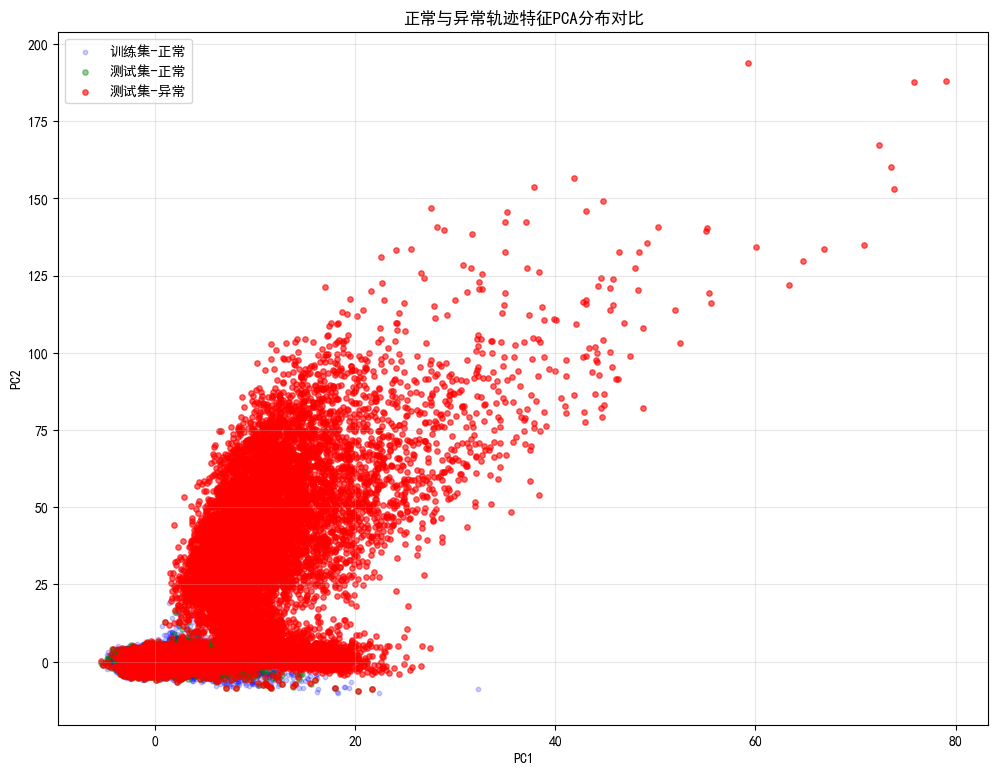

PCA前两个主成分解释方差占比: 46.14%


In [50]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_std)
train_pca = pca.transform(X_train_std)
test_pca = pca.transform(X_test)

plt.figure(figsize=(12, 9))
normal_mask = y_test == 0
abnormal_mask = y_test == 1
plt.scatter(train_pca[:, 0], train_pca[:, 1], c='blue', alpha=0.2, s=10, label='训练集-正常')
plt.scatter(test_pca[normal_mask, 0], test_pca[normal_mask, 1], c='green', alpha=0.4, s=15, label='测试集-正常')
plt.scatter(test_pca[abnormal_mask, 0], test_pca[abnormal_mask, 1], c='red', alpha=0.6, s=15, label='测试集-异常')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('正常与异常轨迹特征PCA分布对比')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/figures/pca_normal_abnormal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PCA前两个主成分解释方差占比: {np.sum(pca.explained_variance_ratio_):.2%}")

### 6.2 不同异常类型的分布对比

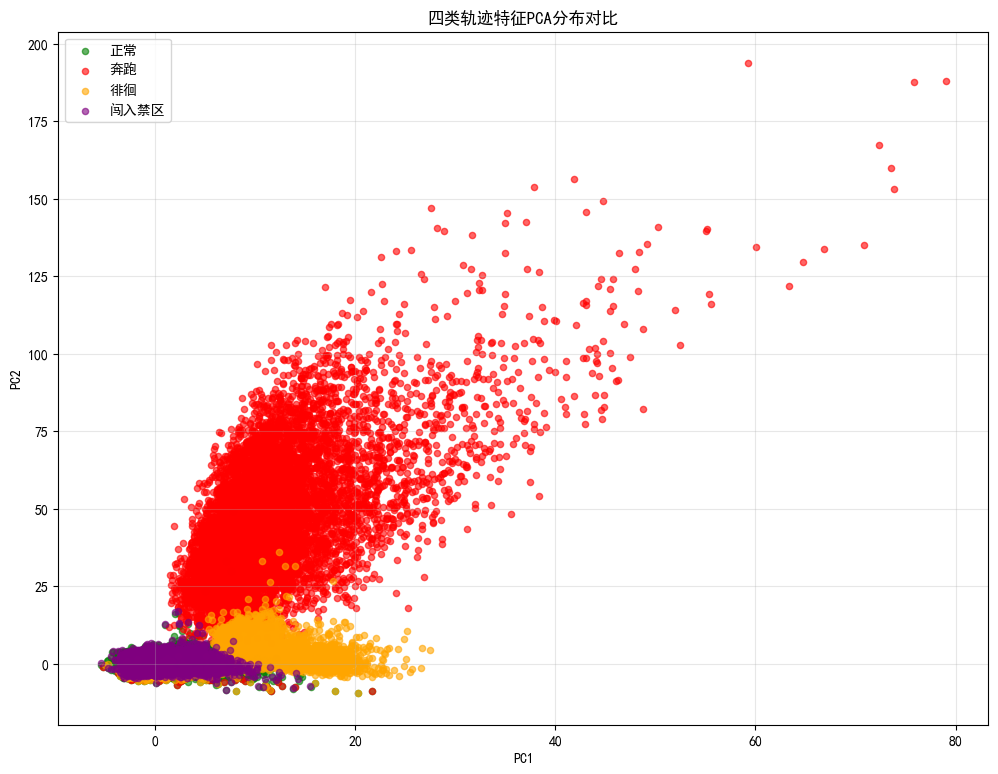

In [51]:
plt.figure(figsize=(12, 9))
colors = ['green', 'red', 'orange', 'purple']
labels = ['正常', '奔跑', '徘徊', '闯入禁区']
for i in range(4):
    mask = test_type_labels == i
    plt.scatter(test_pca[mask, 0], test_pca[mask, 1], 
                c=colors[i], alpha=0.6, s=20, label=labels[i])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('四类轨迹特征PCA分布对比')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/figures/pca_4_types.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 t-SNE非线性降维可视化

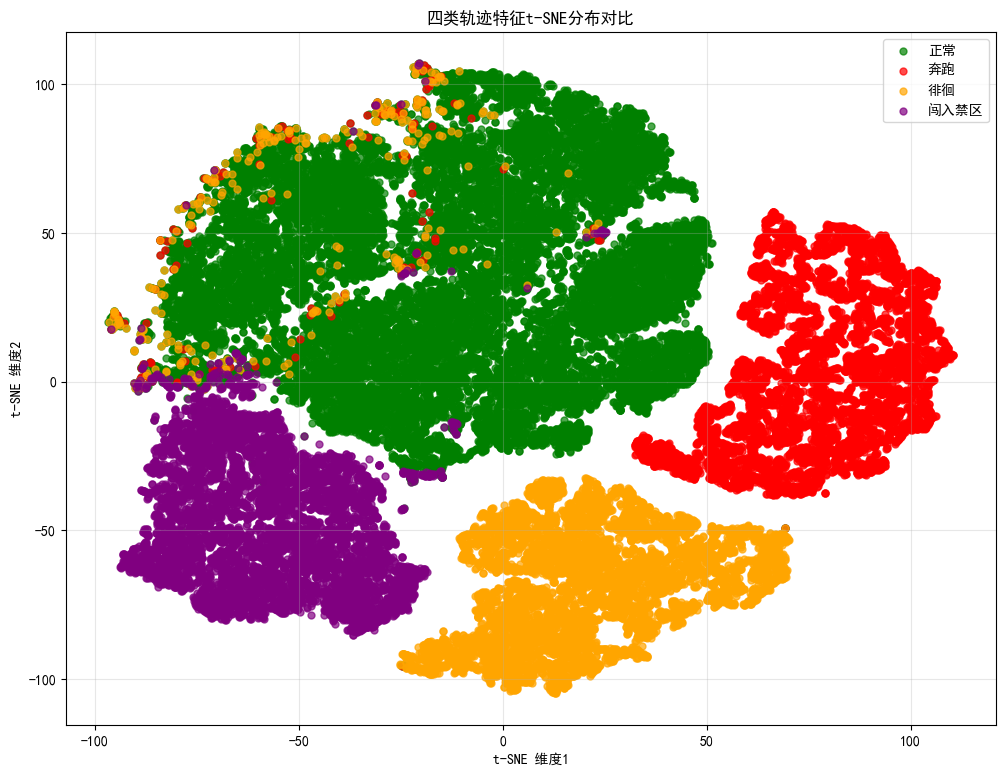

In [52]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    init='pca',
    learning_rate='auto'
)
test_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(12, 9))
for i in range(4):
    mask = test_type_labels == i
    plt.scatter(test_tsne[mask, 0], test_tsne[mask, 1], 
                c=colors[i], alpha=0.7, s=25, label=labels[i])
plt.xlabel('t-SNE 维度1')
plt.ylabel('t-SNE 维度2')
plt.title('四类轨迹特征t-SNE分布对比')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/figures/tsne_4_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 七、保存所有划分结果

In [53]:
# 保存训练集
np.save(os.path.join(processed_path, 'X_train.npy'), X_train_std)
np.save(os.path.join(processed_path, 'train_idx.npy'), train_idx)

# 保存测试集
np.save(os.path.join(processed_path, 'X_test.npy'), X_test)
np.save(os.path.join(processed_path, 'y_test.npy'), y_test)
np.save(os.path.join(processed_path, 'test_type_labels.npy'), test_type_labels)

# 保存禁区坐标
np.save(os.path.join(processed_path, 'forbidden_zone.npy'), np.array([forbid_x, forbid_y]))

print("所有划分结果已保存到 data/processed/ 目录")
print("可直接用于下一阶段的聚类算法与异常检测评估")

所有划分结果已保存到 data/processed/ 目录
可直接用于下一阶段的聚类算法与异常检测评估
